# Statistical Thinking in Python (Part 2) from Datacamp
This Notebook is a mere personal note that I am writing for keep a track of my learning. Dont consider this as what to learn from the DataCamp course.

**Your statistical thinking skills**
* Perform EDA:
Generate effective plots like ECDFs, 
Compute summary statistics
* Estimate parameters:
By optimization, including linear regression, 
Determine confidence intervals
* Formulate and test hypotheses

# Chapter 1

Packages to do Statistical Inferences:
1. Scipy.stats
1. statmodels
1. Hacker stat with Numpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nohitter_times = pd.read_csv("https://assets.datacamp.com/production/repositories/470/datasets/593c37a3588980e321b126e30873597620ca50b7/mlb_nohitters.csv")


In [ ]:
nohitter_times

In [ ]:
# Let's plot PDF of exponential distribution
# Seed random number generator
SEED = np.random.seed(42)

# Compute mean no-hitter time: tau
tau = np.mean(nohitter_times.iloc[:,1])

# Draw out of an exponential distribution with parameter tau: inter_nohitter_time
inter_nohitter_time = np.random.exponential(tau, 100000)

# Plot the PDF and label axes
_ = plt.hist(inter_nohitter_time,
             bins=50, histtype='step') # normed=True, 
_ = plt.xlabel('Games between no-hitters')
_ = plt.ylabel('PDF')

# Show the plot
plt.show()


Theoratical and empirical distribution:
Empirical CDF is build on actual data. Empirical distribution changes with data. 
an empirical distribution is determined by the sample, whereas a theoretical distribution can determine the sample coming out of it. [Source](https://stats.stackexchange.com/questions/237237/what-is-the-difference-between-the-theoretical-distribution-and-the-empirical-di)

**Optimal parameters:**
Parameter values that bring the model in closest agreement with the data

# Chapter 2: Generating Bootstrap replicates

**Bootstraping:** The use of resampled data to perform statistical inference

In [ ]:
# Compute a bootstrape replicate
bs_replicates = np.empty(10000)

# Confidence interval
# confidence_interval = np.percentile()
# will work on it later!
# https://numpy.org/doc/stable/reference/generated/numpy.percentile.html

### Visualizing bootstrap samples
In this exercise, you will generate bootstrap samples from the set of annual rainfall data measured at the Sheffield Weather Station in the UK from 1883 to 2015. The data are stored in the NumPy array rainfall in units of millimeters (mm). By graphically displaying the bootstrap samples with an ECDF, you can get a feel for how bootstrap sampling allows probabilistic descriptions of data.

In [ ]:
import pandas
rainfall = pandas.read_csv("https://assets.datacamp.com/production/repositories/470/datasets/129cba08c45749a82701fbe02180c5b69eb9adaf/sheffield_weather_station.csv", error_bad_lines=False,  skiprows=[0,1,2,3,4,5,6,7])


In [ ]:
# rainfall2 = pd.read_csv(rainfall, sep=" ")
rainfall_data = pandas.read_csv("https://assets.datacamp.com/production/repositories/470/datasets/129cba08c45749a82701fbe02180c5b69eb9adaf/sheffield_weather_station.csv", 
                           error_bad_lines=False,  skiprows=[0,1,2,3,4,5,6,7], sep="\s+")
# error_bad_lines: In the original dataset (if u open the link above), we have some formatting issues. The code would throw error if we dont put False
# skiprows: we have 8 lines at the top of the CSV file (before actual header of the dataset starts), we should SKIP them, right?
# sep="\s+": The data points in the file is seperated by spaces, but random spaces, sometime single space, sometime 2 or more spaces 
rainfall  = rainfall_data['rain']

In [ ]:
rainfall

In [ ]:
!pip install dc_stat_think
import dc_stat_think as dcst # needed to calculate ECDF

In [ ]:
for _ in range(50):
    # Generate bootstrap sample: bs_sample
    
    bs_sample = np.random.choice(rainfall, size=10*len(rainfall))

    # Compute and plot ECDF from bootstrap sample
    x, y = dcst.ecdf(bs_sample)
    _ = plt.plot(x, y, marker= '2', linestyle='none',
                 color='black')
# detail on Marker https://matplotlib.org/3.1.0/api/markers_api.html
# a marker of ',' is tiny compared to '.'

# Compute and plot ECDF from original data
x, y = dcst.ecdf(rainfall)
_ = plt.plot(x, y, marker=',', color='blue')

# Make margins and label axes
plt.margins(0.02)
_ = plt.xlabel('yearly rainfall (mm)')
_ = plt.ylabel('ECDF')

# Show the plot
plt.show()

A typical screen of DataCamp; impressive, right?
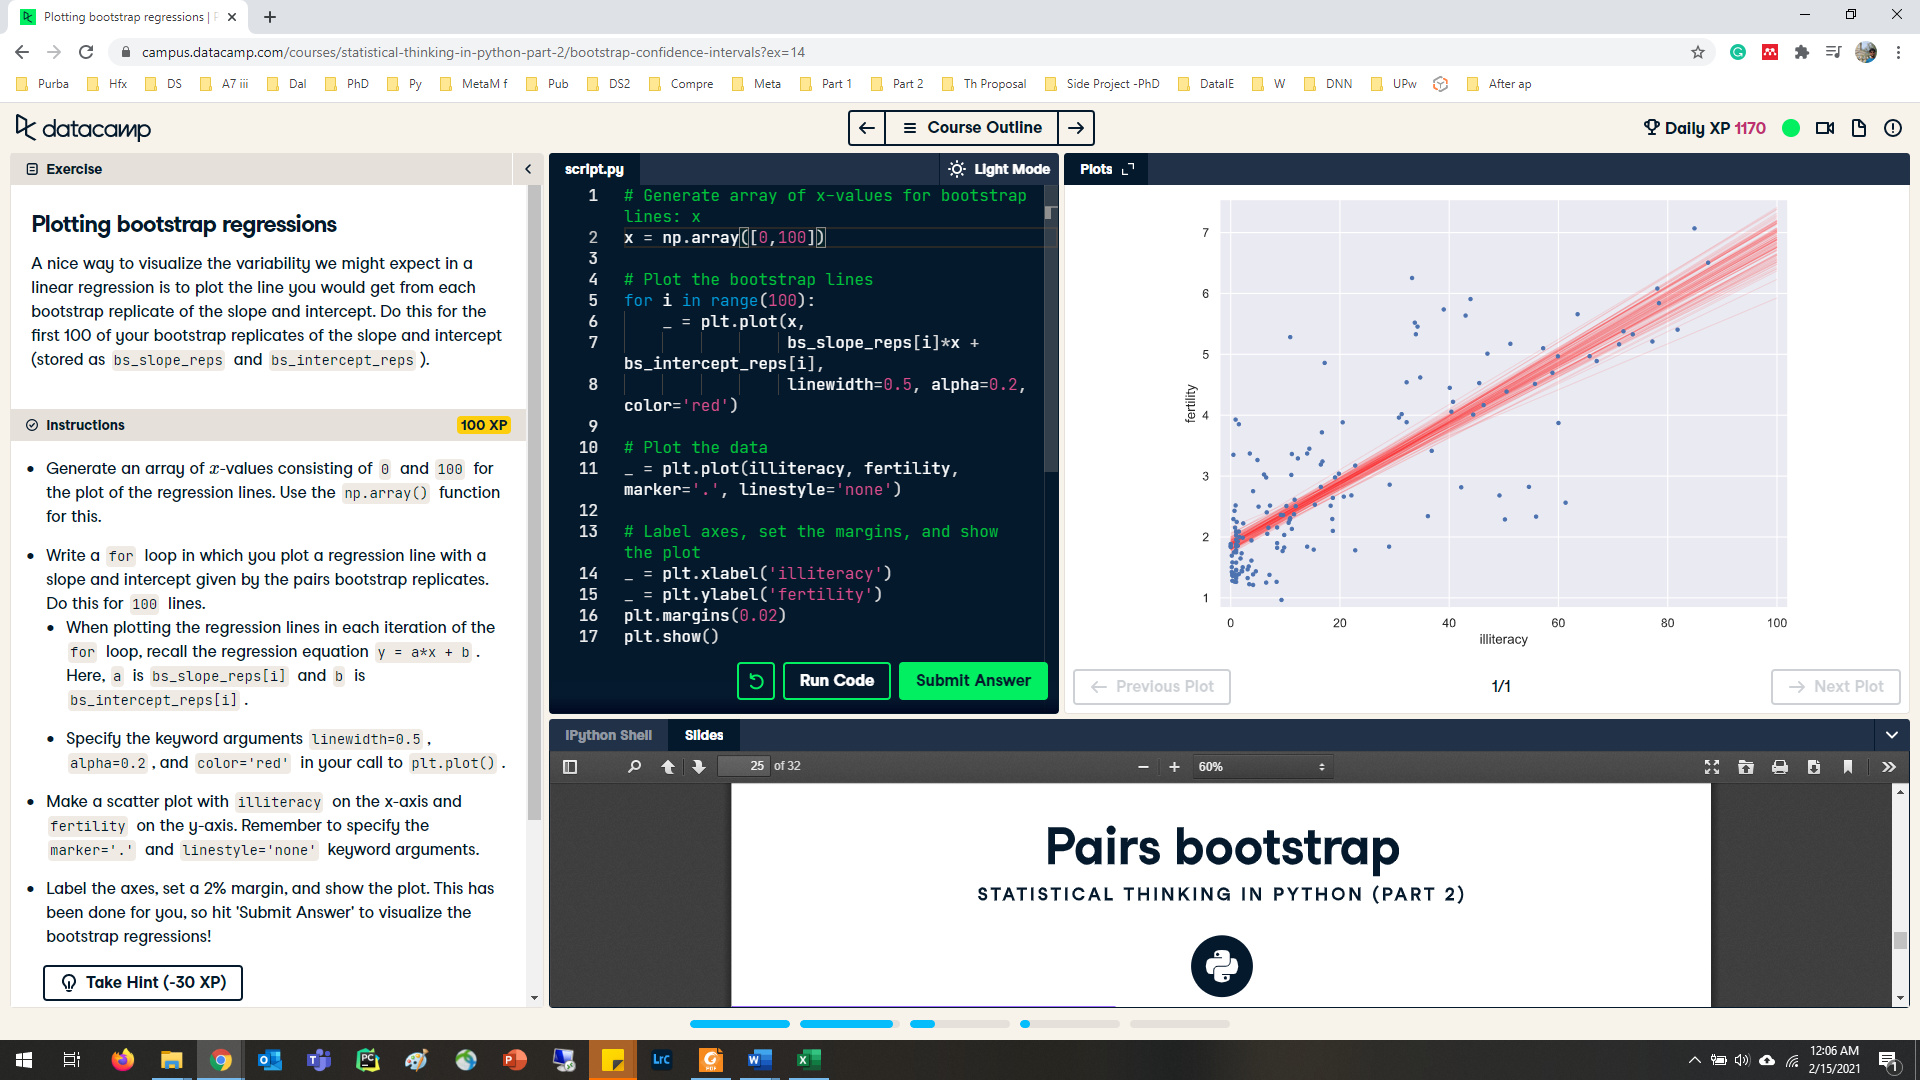

# Chapter 3: Formulating and simulating a Hypothesis

Test statistics: A single number that can be computed from observed data and from data you simulate under the null hypothesis


**Pipeline for hypothesis testing**
* Clearly state the null hypothesis
* Define your test statistic
* Generate many sets of simulated data assuming the null hypothesis is true
* Compute the test statistic for each simulated data set
* The p-value is the fraction of your simulated data sets for which the test statistic is at least as extreme as for the real data



In [ ]:
# Bootstrap confidence interval
conf_int = np.percentile(bs_sample, [2.5, 97.5])
conf_int

# Chapter 4: A/B Testing

A/B test: compare a new model/design with old one

Used by organizations to see if a strategy change gives a better result


Null Hypothesis: Performance of the system is NOT affected by change 

Lower p-value indicates new model/design is better! 

impervious means impenetrable 


# Chapter 5: Finch Beaks and the need for Statistics


Displaying the linear regression results

Python Code:

_ = plt.plot(bl_1975, bd_1975, marker='.',
             linestyle='none', color='blue', alpha=0.5)

_ = plt.plot(bl_2012, bd_2012, marker='.',
             linestyle='none', color='red', alpha=0.5)

_ = plt.xlabel('beak length (mm)')
_ = plt.ylabel('beak depth (mm)')
_ = plt.legend(('1975', '2012'), loc='upper left')

x = np.array([10, 17])

for i in range(100):
    plt.plot(x, bs_intercept_reps_1975[i]+ bs_slope_reps_1975[i]*x,
             linewidth=0.5, alpha=0.2, color='blue')
    plt.plot(x,  bs_intercept_reps_2012[i]+ bs_slope_reps_2012[i]*x,
             linewidth=0.5, alpha=0.2, color='red')
plt.show()

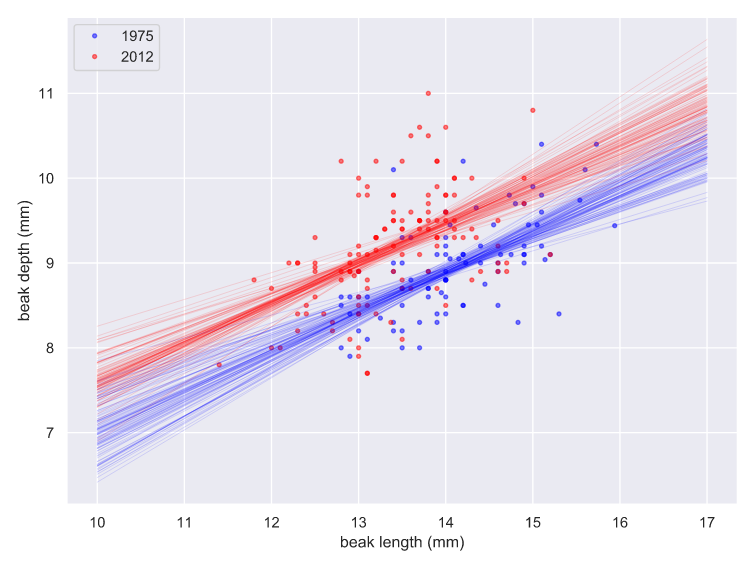